In [1]:
# Данный ноутбук принимает на вход таблицу формата csv, содержащую следующие колонки:
# Год: int
# Муниципалитет: str
# Пол: str
# Возрастная группа: str
# Причина смерти: str
# Стандартный вес группы: str, должен быть указан в процентах (например '4,4')
# Число умерших: int
# Численность населения: int, имеется в виду численность населения возрастной группы

In [2]:
import pandas as pd
import numpy as np
from scipy import stats
import math
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.max_colwidth', None)

In [3]:
# Загрузка исходной таблицы.
df = pd.read_csv("Тестовое _ Данные - Лист1.csv")

In [4]:
# Определение уровня значимости, который будет использоваться для расчётов.
alpha = 0.05
# Расчёт уровня доверия.
CL = int((1-alpha)*100)

# Содержание таблицы

In [5]:
df.head(50)

,Год,Муниципалитет,Пол,Возрастная группа,Причина смерти,Стандартный вес группы,Число умерших,Численность населения
0,2017,Район 1,Женщины,1-4,Болезни сердца,4,0,155
1,2017,Район 1,Женщины,1-4,Другие болезни органов дыхания,4,0,155
2,2017,Район 1,Женщины,1-4,Другие болезни системы кровообращения,4,0,155
3,2017,Район 1,Женщины,1-4,Острые респираторные заболевания,4,0,155
4,2017,Район 1,Женщины,10-14,Болезни сердца,"5,5",0,163
5,2017,Район 1,Женщины,10-14,Другие болезни органов дыхания,"5,5",0,163
6,2017,Район 1,Женщины,10-14,Другие болезни системы кровообращения,"5,5",0,163
7,2017,Район 1,Женщины,10-14,Острые респираторные заболевания,"5,5",0,163
8,2017,Район 1,Женщины,15-19,Болезни сердца,"5,5",0,132
9,2017,Район 1,Женщины,15-19,Другие болезни органов дыхания,"5,5",0,132


In [6]:
# Диапазоны значений колонок
print('Диапазоны значений колонок:', '\n')

for column in df.columns:
    print(column, df[column].unique().tolist(), '\n')

Диапазоны значений колонок: 

Год [2017, 2018, 2019, 2020, 2021, 2022, 2023] 

Муниципалитет ['Район 1', 'Район 2', 'Район 3'] 

Пол ['Женщины', 'Мужчины'] 

Возрастная группа ['1-4', '10-14', '15-19', '20-24', '25-29', '30-34', '35-39', '40-44', '45-49', '5-9', '50-54', '55-59', '60-64', '65-69', '70-74', '75-79', '80-84', '85+', 'до 1'] 

Причина смерти ['Болезни сердца', 'Другие болезни органов дыхания', 'Другие болезни системы кровообращения', 'Острые респираторные заболевания'] 

Стандартный вес группы ['4', '5,5', '6', '6,5', '7', '5', '2,5', '1'] 

Число умерших [0, 1, 2, 3, 4, 8, 10, 5, 11, 13, 6, 12, 7, 9] 

Численность населения [155, 163, 132, 135, 122, 131, 144, 133, 152, 342, 143, 159, 105, 54, 35, 11, 2, 21, 116, 129, 94, 100, 147, 149, 354, 174, 164, 141, 83, 71, 28, 16, 17, 112, 72, 96, 118, 74, 84, 202, 89, 82, 24, 7, 1, 22, 98, 113, 91, 49, 125, 86, 242, 95, 103, 88, 59, 44, 15, 10, 27, 781, 835, 661, 654, 994, 1223, 1172, 899, 718, 958, 849, 933, 732, 493, 217, 334, 

# Вычисление коэффициентов

## Приведение входных данных к удобному виду

In [7]:
# Приведение колонки 'Стандартный вес группы' исходной таблицы к виду 0.01 (т.е. доли, а не проценты).
df['Стандартный вес группы'] = df['Стандартный вес группы'].str.replace(',', '.').astype(float) / 100

## Функции

In [8]:
def get_slice(
    df: pd.DataFrame,
    district: str,
    year: int,
    target: str = None):

    """
    Делает срез по исходным данным по требуемым в задании параметрам.
    df: исходный датафрейм
    district: муниципалитет
    year: год
    target: пол, причина смерти или None
    Возвращает датафрейм формата входных данных.
    """
    if year is None:
        if target is None:
            df_slice = (df[(df['Муниципалитет']==district)]
                .groupby(['Возрастная группа', 'Стандартный вес группы', 'Пол'], as_index=False)
                .agg({'Число умерших': 'sum', 'Численность населения': 'mean'}))
            df_slice = (df_slice.groupby(['Возрастная группа', 'Стандартный вес группы'], as_index=False)
                .agg({'Число умерших': 'sum', 'Численность населения': 'sum'}))
        
        elif target in df['Причина смерти'].unique():
            df_slice = (df[(df['Муниципалитет']==district)&(df['Причина смерти']==target)]
                .groupby(['Возрастная группа', 'Стандартный вес группы', 'Пол'], as_index=False)
                .agg({'Число умерших': 'sum', 'Численность населения': 'mean'}))
            df_slice = (df_slice.groupby(['Возрастная группа', 'Стандартный вес группы'], as_index=False)
                .agg({'Число умерших': 'sum', 'Численность населения': 'sum'}))
        
        elif target in df['Пол'].unique():
            df_slice = (df[(df['Муниципалитет']==district)&(df['Пол']==target)]
                .groupby(['Возрастная группа', 'Стандартный вес группы'], as_index=False)
                .agg({'Число умерших': 'sum', 'Численность населения': 'mean'}))
        
        else:
            raise ValueError("Неверное значение target, выполнение прервано")
    
    else:
        if target is None:
            df_slice = (df[(df['Муниципалитет']==district)&(df['Год']==year)]
                .groupby(['Возрастная группа', 'Стандартный вес группы', 'Пол'], as_index=False)
                .agg({'Число умерших': 'sum', 'Численность населения': 'first'}))
            df_slice = (df_slice.groupby(['Возрастная группа', 'Стандартный вес группы'], as_index=False)
                .agg({'Число умерших': 'sum', 'Численность населения': 'sum'}))
        
        elif target in df['Причина смерти'].unique():
            df_slice = (df[(df['Муниципалитет']==district)&(df['Год']==year)&(df['Причина смерти']==target)]
                .groupby(['Возрастная группа', 'Стандартный вес группы', 'Пол'], as_index=False)
                .agg({'Число умерших': 'sum', 'Численность населения': 'first'}))
            df_slice = (df_slice.groupby(['Возрастная группа', 'Стандартный вес группы'], as_index=False)
                .agg({'Число умерших': 'sum', 'Численность населения': 'sum'}))
        
        elif target in df['Пол'].unique():
            df_slice = (df[(df['Муниципалитет']==district)&(df['Год']==year)&(df['Пол']==target)]
                .groupby(['Возрастная группа', 'Стандартный вес группы'], as_index=False)
                .agg({'Число умерших': 'sum', 'Численность населения': 'first'}))
        
        else:
            raise ValueError("Неверное значение target, выполнение прервано")
        
    return df_slice

In [9]:
def N_D_SCR_CI_calc(
    df: pd.DataFrame,
    alpha: float = 0.05):

    """
    Рассчитывает cуммарную численность населения, суммарное число умерших,
    стандартизованный коэффициент смертности, нижнюю и верхнюю границы доверительного интервала для СКС,
    статистическую значимость отличия СКС от нуля по исходной таблице.
    Границы доверительного интервала рассчитываются методом нормального приближения распределения Пуассона для числа смертей больше 25
    и методом Добсона для числа смертей от 10 до 25. При числе смертей меньше 10 в качестве значений границ возвращается None.
    df: датафрейм формата исходных данных
    alpha: уровень значимости
    Возвращает суммарную численность населения,суммарное число умерших,
    стандартизованный коэффициент смертности, нижнюю и верхнюю границы доверительного интервала для СКС,
    статистическую значимость отличия СКС от нуля.
    """
    
    # Создание колонки 'Коэффициент смертности'.
    df['Коэффициент смертности'] = df['Число умерших'] / df['Численность населения']
    # Вычисление суммарной численности населения по срезу.
    N = df['Численность населения'].sum()
    # Вычисление суммарного числа умерших по срезу.
    D = df['Число умерших'].sum()
    # Вычисление стандартизованного коэффициента смертности на 100000 человек для среза.
    SCR = (df['Коэффициент смертности'] * df['Стандартный вес группы']).sum() * 100000
    if D > 9:
        if D < 25:
            # Вычисление стандартной ошибки стандартизованного коэффициента смертности на 100000 человек для среза (метод Добсона).
            LCL = SCR + ((((df['Стандартный вес группы'].pow(2) * df['Коэффициент смертности'] / df['Численность населения']).sum() /
                           df['Число умерших'].sum()) ** 0.5)
                         * (stats.chi2.ppf(alpha/2, 2 * df['Число умерших'].sum())/2 - df['Число умерших'].sum()) * 100000)
            UCL = SCR + ((((df['Стандартный вес группы'].pow(2) * df['Коэффициент смертности'] / df['Численность населения']).sum() /
                           df['Число умерших'].sum()) ** 0.5)
                         * (stats.chi2.ppf(1 - alpha/2, 2 * df['Число умерших'].sum() + 2)/2 - df['Число умерших'].sum()) * 100000)
        else:
            # Вычисление стандартной ошибки стандартизованного коэффициента смертности на 100000 человек для среза
            # (пуассоновская аппроксимация нормального распределения).
            LCL = SCR + (((df['Стандартный вес группы'].pow(2) * df['Коэффициент смертности'] / df['Численность населения']).sum() ** 0.5)
                         * stats.norm.ppf(alpha/2) * 100000)
            UCL = SCR + (((df['Стандартный вес группы'].pow(2) * df['Коэффициент смертности'] / df['Численность населения']).sum() ** 0.5)
                         * stats.norm.ppf(1 - alpha/2) * 100000)
        # Определение статистической значимости отличия СКС от нуля.
        if LCL > 0:
            return N.item(), D.item(), SCR.item(), LCL.item(), UCL.item(), 'Да'
        else:
            return N.item(), D.item(), SCR.item(), LCL.item(), UCL.item(), 'Нет'
    else:
        return N.item(), D.item(), SCR.item(), None, None, 'Нет'

In [10]:
def N_D_SCR_CI_by_slice(
    df: pd.DataFrame,
    district: str,
    year: int = None,
    target: str = None,
    alpha: int = 0.05):

    """
    Расчитывает суммарную численность населения, суммарное число умерших,
    стандартизованный коэффициент смертности и границы доверительного интервала для СКС
    посредством функций get_slice и N_SCR_CI_calc.
    df: исходный датафрейм
    district: муниципалитет
    year: год
    target: пол, причина смерти или None
    Возвращает суммарную численность населения,суммарное число умерших,
    стандартизованный коэффициент смертности, нижнюю и верхнюю границы доверительного интервала для СКС.
    """
    
    # Создание таблицы среза через вызов функции get_slice.
    df_slice = get_slice(df=df, district=district, year=year, target=target)
    return N_D_SCR_CI_calc(df_slice, alpha)

## Вычисление

In [11]:
# Создание списка годов.
all_years_list = df['Год'].unique().tolist()
# Создание списка причин смерти.
all_causes_list = df['Причина смерти'].unique().tolist()
# Создание списка муниципалитетов.
all_districts_list = df['Муниципалитет'].unique().tolist()
# Создание списка полов.
all_genders_list = df['Пол'].unique().tolist()

### Вычисление по годам

In [12]:
# Создание набора данных из всех комбинаций всех уникальных значений колонок 'Муниципалитет' и 'Год'.
targets_district_year_list = [[x, y] for x in df['Муниципалитет'].unique() for y in df['Год'].unique()]

# Создание набора данных из всех комбинаций всех уникальных значений колонок 'Муниципалитет', 'Год' и 'Пол'.
targets_district_year_gender_list = [[x, y, z] for x in df['Муниципалитет'].unique() \
                                    for y in df['Год'].unique() for z in df['Пол'].unique()]

# Создание набора данных из всех комбинаций всех уникальных значений колонок 'Муниципалитет', 'Год' и 'Причина смерти'.
targets_district_year_death_cause_list = [[x, y, z] for x in df['Муниципалитет'].unique() \
                                          for y in df['Год'].unique() for z in df['Причина смерти'].unique()]

In [13]:
# Названия колонок будующей таблицы с суммарным разрезом и разрезами по гендеру и причинам смерти.

columns_list = ['Муниципалитет', 'Год', 'Пол', 'Причина смерти', 'Численность населения', 'Число умерших', 'СКС',
                'Нижняя граница ДИ ({}%)'.format(CL), 'Верхняя граница ДИ ({}%)'.format(CL), 'Значимость СКС (p < {})'.format(alpha)]

In [14]:
# Суммарный разрез (объединяет данные по гендеру и причинам смерти сохраняя муниципалитет и год).
# Расчёт значений суммарной численности населения, суммарного числа умерших, СКС и границ ДИ для СКС,
# и включение этих данных в содержимое листа result_district_year_list
result_district_year_list = [row + ['Все', 'Все'] + list(N_D_SCR_CI_by_slice(df, row[0], row[1])) \
                             for row in targets_district_year_list]
# Создание датафрейма
df_result_district_year = pd.DataFrame(result_district_year_list, columns=columns_list)

# Разрез по гендеру (объединяет данные по гендеру сохраняя муниципалитет, год и причины смерти)
# Расчёт значений суммарной численности населения, суммарного числа умерших, СКС и границ ДИ для СКС,
# и включение этих данных в содержимое листа result_district_year_gender_list
result_district_year_gender_list = [row + ['Все'] + list(N_D_SCR_CI_by_slice(df, row[0], row[1], row[2])) \
                             for row in targets_district_year_gender_list]
# Создание датафрейма
df_result_district_year_gender = pd.DataFrame(result_district_year_gender_list, columns=columns_list)

# Разрез по причинам смерти (объединяет данные по причинам смерти сохраняя муниципалитет, год и гендер)
# Расчёт значений суммарной численности населения, суммарного числа умерших, СКС и границ ДИ для СКС,
# и включение этих данных в содержимое листа result_district_year_death_cause_list
result_district_year_death_cause_list = [[row[0], row[1], 'Все', row[2]] + list(N_D_SCR_CI_by_slice(df, row[0], row[1], row[2])) \
                             for row in targets_district_year_death_cause_list]
# Создание датафрейма
df_result_district_year_death_cause = pd.DataFrame(result_district_year_death_cause_list, columns=columns_list)

# Создание общего датафрейма
df_result = pd.concat([df_result_district_year, df_result_district_year_gender, df_result_district_year_death_cause], ignore_index=True)

In [15]:
df_result.head(50)

,Муниципалитет,Год,Пол,Причина смерти,Численность населения,Число умерших,СКС,Нижняя граница ДИ (95%),Верхняя граница ДИ (95%),Значимость СКС (p < 0.05)
0,Район 1,2017,Все,Все,4445,19,858.284639,426.487902,1467.699628,Да
1,Район 1,2018,Все,Все,4409,14,597.988649,269.861858,1088.654377,Да
2,Район 1,2019,Все,Все,4378,11,379.817689,152.223196,738.511042,Да
3,Район 1,2020,Все,Все,4346,25,1051.377639,575.258503,1527.496775,Да
4,Район 1,2021,Все,Все,4226,22,823.436035,491.573908,1280.384036,Да
5,Район 1,2022,Все,Все,4161,35,1297.124613,840.340872,1753.908354,Да
6,Район 1,2023,Все,Все,4105,17,726.123936,330.038842,1296.438972,Да
7,Район 2,2017,Все,Все,2962,15,815.255235,432.763410,1379.338794,Да
8,Район 2,2018,Все,Все,2956,7,300.620512,NaN,NaN,Нет
9,Район 2,2019,Все,Все,2941,8,556.633277,NaN,NaN,Нет


In [16]:
# Подготовка таблицы для выгрузки: только нужные колонки.
df_export = df_result[['Муниципалитет', 'Год', 'Пол', 'Причина смерти', 'СКС']].copy()
# Сохранение в CSV.
df_export.to_csv('СКС_результаты.csv', index=False, encoding='utf-8-sig')

# Округление до целых.
df_export['СКС'] = df_export['СКС'].round(0).astype(int)
# Сохранение в CSV.
df_export.to_csv('СКС_результаты_округление_до_целых.csv', index=False, encoding='utf-8-sig')

# Интерпретация

## Функции

### Статика

In [17]:
def comparison(
    SCR_1: float,
    LCL_1: float,
    UCL_1: float,
    SCR_2: float,
    LCL_2: float,
    UCL_2: float):

    """
    Рассчитывает значимость различия между двумя значениями стандартизованного коэффициента смертности и показывает какое из них больше.
    Если >, то первое, если <, то второе.
    SCR_1: первый стандартизованный коэффициент смертности
    LCL_1: нижняя граница ДИ для первого СКС
    UCL_1: верхняя граница ДИ для первого СКС
    SCR_2: второй стандартизованный коэффициент смертности
    LCL_2: нижняя граница ДИ для второго СКС
    UCL_2: верхняя граница ДИ для второго СКС
    Возвращает статистически значимое отличие SCR_1 от SCR_2 в формате '>', '=', '<' или None
    в случае незначимости данных по хотябы одной группе.
    """
    
    # Проверка на значимость данных элементов сравниваемой пары.
    if LCL_1 is None or np.isnan(LCL_1) or LCL_2 is None or np.isnan(LCL_2):
        return None
    
    # Проверка на равенство нулю обоих стандартизованных коэффициентов смертности.
    if SCR_1 == 0 and SCR_2 == 0:
        return '='

    if SCR_1 > SCR_2:
        if LCL_1 > UCL_2:
            return '>'
        else:
            return '='
    if SCR_1 < SCR_2:
        if UCL_1 < LCL_2:
            return '<'
        else:
            return '='

In [18]:
def d2d_comparision(df: pd.DataFrame,
                    year: int,
                    district_1: str,
                    district_2: str,
                    param: list,
                    alpha: float = 0.05):
    '''
    Создаёт два среза для сопоставления и передаёт их в функцию comparison.
    df: исходная таблица
    year: год
    district_1: муниципалитет 1
    district_2: муниципалитет 2
    param: как минимум одно значение из набора полов или из набора причина смерти
    alpha: уровень значимости
    Возвращает статистически значимое отличие SCR_1 от SCR_2 в формате '>', '=', '<' или None
    в случае незначимости данных по хотябы одной группе.
    '''
    if year is None:
        slice_1 = df[(df['Муниципалитет']==district_1)&((df['Пол'].isin(param))|(df['Причина смерти'].isin(param)))]
        slice_2 = df[(df['Муниципалитет']==district_2)&((df['Пол'].isin(param))|(df['Причина смерти'].isin(param)))]
    else:
        slice_1 = df[(df['Год']==year)&(df['Муниципалитет']==district_1)&((df['Пол'].isin(param))|(df['Причина смерти'].isin(param)))]
        slice_2 = df[(df['Год']==year)&(df['Муниципалитет']==district_2)&((df['Пол'].isin(param))|(df['Причина смерти'].isin(param)))]
    N_1, D_1, SCR_1, LCL_1, UCL_1, significance_1 =  N_D_SCR_CI_calc(slice_1, alpha)
    N_2, D_2, SCR_2, LCL_2, UCL_2, significance_2 =  N_D_SCR_CI_calc(slice_2, alpha)
    return comparison(SCR_1, LCL_1, UCL_1, SCR_2, LCL_2, UCL_2)

In [19]:
def in_district_comparision(df: pd.DataFrame,
                            year: int,
                            district: str,
                            param_1: list,
                            param_2: list,
                            alpha: float = 0.05):
    '''
    Создаёт два среза для сопоставления и передаёт их в функцию comparison.
    df: исходная таблица
    year: год
    district: муниципалитет
    param_1: как минимум одно значение из набора полов или из набора причина смерти
    param_2: как минимум одно значение из набора полов или из набора причина смерти
    alpha: уровень значимости
    Возвращает статистически значимое отличие SCR_1 от SCR_2 в формате '>', '=', '<' или None
    в случае незначимости данных по хотябы одной группе.
    '''
    if year is None:
        slice_1 = df[(df['Муниципалитет']==district)&((df['Пол'].isin(param_1))|(df['Причина смерти'].isin(param_1)))]
        slice_2 = df[(df['Муниципалитет']==district)&((df['Пол'].isin(param_2))|(df['Причина смерти'].isin(param_2)))]
    else:
        slice_1 = df[(df['Год']==year)&(df['Муниципалитет']==district)&((df['Пол'].isin(param_1))|(df['Причина смерти'].isin(param_1)))]
        slice_2 = df[(df['Год']==year)&(df['Муниципалитет']==district)&((df['Пол'].isin(param_2))|(df['Причина смерти'].isin(param_2)))]
    N_1, D_1, SCR_1, LCL_1, UCL_1, significance_1 =  N_D_SCR_CI_calc(slice_1, alpha)
    N_2, D_2, SCR_2, LCL_2, UCL_2, significance_2 =  N_D_SCR_CI_calc(slice_2, alpha)
    return comparison(SCR_1, LCL_1, UCL_1, SCR_2, LCL_2, UCL_2)

### Динамика

In [20]:
def weighted_regression(
    df_slice: pd.DataFrame,
    alpha: float = 0.05):
    """
    Рассчитывает взвешенную линейную регрессию для среза по требуемым параметрам муниципалитета, пола и причины смерти.
    df: датафрейм формата df_result
    alpha: уровень значимости
    Возвращает угловой коэффициент регрессии и его значимость в формате 'Да' или 'Нет'.
    """
    # получение среза
    # df_slice = df[(df['Муниципалитет']==district)&(df['Пол']==gender)&(df['Причина смерти']==death_cause)&(df['Стандартная ошибка']!=0)]
    # удаление строк без границ ДИ
    df_slice.dropna(ignore_index=True, inplace=True)
    # вычисление уровня доверия
    CL = int((1-alpha)*100)
    # создание колонки 'Стандартная ошибка'
    df_slice['Стандартная ошибка'] = 0.5*(df_slice['Нижняя граница ДИ ({}%)'.format(CL)] -
                                          df_slice['Верхняя граница ДИ ({}%)'.format(CL)])/stats.norm.ppf(1 - alpha/2)
    # получение количества точек
    n_elements = df_slice.shape[0]
    if n_elements < 4:
        return None, 'В группе недостаточно случаев'
    # получение вектора годов (ось x)
    x = np.array(df_slice['Год'])
    # получение вектора стандартизованных коэффициентов смертности (ось y)
    y = np.array(df_slice['СКС'])
    # получение вектора весов
    weights = 1 / np.array(df_slice['Стандартная ошибка'])**2

    # получение суммы весов
    weights_sum = weights.sum()
    # получение взвешенного среднего для годов (ось x)
    x_weights = np.sum(weights * x) / weights_sum
    # получение взвешенного среднего для стандартизованных коэффициентов смертности (ось y)
    y_weights = np.sum(weights * y) / weights_sum
    
    # получение числителя для углового коеффициента регрессии (b)
    b_numerator = np.sum(weights * (x - x_weights) * (y - y_weights))
    # получение знаменателя для углового коеффициента регрессии (b)
    b_denominator = np.sum(weights * (x - x_weights)**2)
    # защита от деления на 0
    if b_denominator == 0:
        raise ValueError("Нулевой знаменатель — невозможно оценить тренд")
    # получение углового коеффициента регрессии (b)
    b = b_numerator / b_denominator
    # получение сдвига регрессии (a)
    a = y_weights - b * x_weights
    
    # получение остатков (которые дальше будут минимизироваться)
    residuals = y - (a + b * x)
    # получение взвешенной дисперсии остатков
    sigma2 = np.sum(weights * residuals**2) / (n_elements - 2)
    # получение стандартной ошибки углового коэффициента регрессии (b)
    se_b = np.sqrt(sigma2 / b_denominator)
    
    # деление углового коэффициента регрессии на его стандартную ошибку (нужно для оценки его значимости)
    t_stat = b / se_b
    # получение значения функции распределения Стьюдента (возвращает вероятность того, что случайная величина меньше модуля t_stat)
    p_value = 2 * (1 - stats.t.cdf(abs(t_stat), n_elements-2))

    # проверка значимости и вывод
    if p_value < alpha:
        return b.item(), 'Да'
    else:
        return b.item(), 'Нет'

## Вычисление

### Статика по годам

#### Статика между муниципалитетами по годам

In [21]:
# Идея: попарно сравнить различия в стандартизованных коэффициентов смертности между разными муниципалитетами
# для всех комбинаций остальных параметров.

In [22]:
# Создание таблицы срезов для сравнений между муниципалитетами внутри года.
year_list = []
district_1_list = []
district_2_list = []
param_list = []
# Фильтрация по году.
for year in all_years_list:
    # Фильтрация по первому муниципалитету пары.
    for district_1 in all_districts_list:
        # Фильтрация по второму муниципалитету пары.
        for district_2 in all_districts_list:
            # Защита от повторов вида [a, b] и [b, a].
            if district_2 > district_1:
                # Создание списка, куда будут записываться непрошедшие проверку по числу умерших, причины смерти.
                drop_cause_list = []
                # Проверка по чилу умерших для всех причин в паре.
                if df[(df['Муниципалитет']==district_1)&(df['Год']==year)]['Число умерших'].sum()>9 and \
                df[(df['Муниципалитет']==district_2)&(df['Год']==year)]['Число умерших'].sum()>9:
                    # Добавление значений года, муниципалитетов и полов в списки при успешном прохождениии проверки.
                    year_list.append(year)
                    district_1_list.append(district_1)
                    district_2_list.append(district_2)
                    param_list.append(all_genders_list)
                    # Фильтрация по полу.
                    for gender in all_genders_list:
                        # Приверка по числу смертей.
                        if df[(df['Муниципалитет']==district_1)&(df['Пол']==gender)&(df['Год']==year)]['Число умерших'].sum()>9 and \
                        df[(df['Муниципалитет']==district_2)&(df['Пол']==gender)&(df['Год']==year)]['Число умерших'].sum()>9:
                            # Добавление значений года, муниципалитетов и пола в списки при успешном прохождениии проверки.
                            year_list.append(year)
                            district_1_list.append(district_1)
                            district_2_list.append(district_2)
                            param_list.append(gender)
                    # Фильтрация по причине смерти.
                    for cause in all_causes_list:
                        # Проверка по числу смертей.
                        if df[(df['Муниципалитет']==district_1)&(df['Причина смерти']==cause)&
                            (df['Год']==year)]['Число умерших'].sum()>9 and \
                        df[(df['Муниципалитет']==district_2)&(df['Причина смерти']==cause)&
                            (df['Год']==year)]['Число умерших'].sum()>9:
                            # Добавление значений года, муниципалитетов и причины смерти в списки при успешном прохождениии проверки.
                            year_list.append(year)
                            district_1_list.append(district_1)
                            district_2_list.append(district_2)
                            param_list.append(cause)
                        else:
                            # Добавление причины смерти в drop_cause_list в случае непрохождения проверки.
                            drop_cause_list.append(cause)
                    # Проверка на наличие причин смерти в drop_cause_list.
                    if len(drop_cause_list) != 0:
                        # Проверка по числу смертей для всех не прошедших предущие проверки причин смерти вместе.
                        if df[(df['Муниципалитет']==district_1)&(df['Причина смерти'].isin(drop_cause_list))&
                            (df['Год']==year)]['Число умерших'].sum()>9 and \
                        df[(df['Муниципалитет']==district_2)&(df['Причина смерти'].isin(drop_cause_list))&
                            (df['Год']==year)]['Число умерших'].sum()>9:
                            # Добавление значений года, муниципалитетов и причин смерти в списки при успешном прохождениии проверки.
                            year_list.append(year)
                            district_1_list.append(district_1)
                            district_2_list.append(district_2)
                            param_list.append(drop_cause_list)
# Создание таблицы slices_d2d_df.
slices_d2d_df = pd.DataFrame({'Год': year_list, 'Муниципалитет 1': district_1_list,
                              'Муниципалитет 2': district_2_list, 'Параметр': param_list})
# Приведение всех данных колонки 'Параметр' к формату list.
slices_d2d_df['Параметр'] = slices_d2d_df['Параметр'].apply(lambda x: [x] if type(x) != list else x)

# Создание колонки 'Значимое отличие (p < alpha)', содержащей значения '>', '=', '<'.
# '>' значит, что СКС для Параметра в Муниципалитете 1 статистически значимо больше, чем такое же значение СКС в Муниципалитете 2.
# '<' значит, что СКС Муниципалитета 1 меньше СКС Муниципалитета 2 по Параметру. '=' означает, что СКС значимо не различаются.
slices_d2d_df['Значимое отличие (p < {})'.format(alpha)] = slices_d2d_df.apply(
    lambda x: d2d_comparision(df, x['Год'], x['Муниципалитет 1'], x['Муниципалитет 2'], x['Параметр']), axis = 1)
# Приведение всех данных колонки 'Параметр' к формату str.
slices_d2d_df['Параметр'] = slices_d2d_df['Параметр'].apply(
    lambda x: x if type(x)!=list else
    x[0] if len(x)==1 else
    'Все' if all([gender in x for gender in all_genders_list])
    else '|'.join(x))
# Сортировка строк slices_d2d_df.
slices_d2d_df.sort_values(by=['Муниципалитет 1', 'Муниципалитет 2', 'Параметр', 'Год'], ignore_index=True, inplace=True)

In [23]:
slices_d2d_df

,Год,Муниципалитет 1,Муниципалитет 2,Параметр,Значимое отличие (p < 0.05)
0,2017,Район 1,Район 2,Болезни сердца,=
1,2021,Район 1,Район 2,Болезни сердца,=
2,2022,Район 1,Район 2,Болезни сердца,=
3,2023,Район 1,Район 2,Болезни сердца,=
4,2020,Район 1,Район 2,Болезни сердца|Другие болезни органов дыхания|Другие болезни системы кровообращения|Острые респираторные заболевания,=
5,2017,Район 1,Район 2,Все,=
6,2020,Район 1,Район 2,Все,=
7,2021,Район 1,Район 2,Все,=
8,2022,Район 1,Район 2,Все,=
9,2023,Район 1,Район 2,Все,=


In [24]:
# Проверка содержимого колонки 'Значимое отличие (p < alpha)'
slices_d2d_df['Значимое отличие (p < {})'.format(alpha)].unique()

<ArrowStringArray>
['=', '>']
Length: 2, dtype: str

In [25]:
# Словарь замен для расчёта направленности общего различия между группами.
p_dict = {'=': 0, '>': 1, '<': -1}

In [26]:
# Создание колонки "Число значимых измерений" (показывает после схлопывания по годам сколько пар в группе были значимы).
slices_d2d_df['Число значимых измерений'] = \
slices_d2d_df['Значимое отличие (p < {})'.format(alpha)].apply(lambda x: 0 if x is None else 1)
# Создание колонки "Значимое отличие (p < 0.05) int" (где +1 соответствует '>', 0 соответствует '=', -1 соответствует '<').
# Колонка "Значимое отличие (p < 0.05) int" не была сгенерирована сразу т.к. знаки '>', '=', '<' более наглядные.
slices_d2d_df['Значимое отличие (p < {} int)'.format(alpha)] = \
slices_d2d_df['Значимое отличие (p < {})'.format(alpha)].apply(lambda x: p_dict[x])
# Суммирование по колонкам "Число значимых измерений" и "Значимое отличие (p < 0.05) int" внутри каждой группы (схлопывание по годам).
(slices_d2d_df.groupby(['Муниципалитет 1', 'Муниципалитет 2', 'Параметр'], as_index=False)
    [['Значимое отличие (p < {} int)'.format(alpha), 'Число значимых измерений']].sum())

,Муниципалитет 1,Муниципалитет 2,Параметр,Значимое отличие (p < 0.05 int),Число значимых измерений
0,Район 1,Район 2,Болезни сердца,0,4
1,Район 1,Район 2,Болезни сердца|Другие болезни органов дыхания|Другие болезни системы кровообращения|Острые респираторные заболевания,0,1
2,Район 1,Район 2,Все,0,5
3,Район 1,Район 2,Мужчины,0,1
4,Район 1,Район 3,Болезни сердца,1,7
5,Район 1,Район 3,Все,1,7
6,Район 1,Район 3,Женщины,2,3
7,Район 1,Район 3,Мужчины,0,5
8,Район 2,Район 3,Болезни сердца,2,4
9,Район 2,Район 3,Болезни сердца|Другие болезни органов дыхания|Другие болезни системы кровообращения|Острые респираторные заболевания,0,1


In [27]:
# Короткий вывод:
# 1) Район 1 и Район 2 не отличаются по структуре смертности.
# 2) В Районе 3 женская смертность, смерность ото всех причин и смертность от болезней сердца ниже, чем в Районе 1.
# 3) В Районе 3 смертность от болезней сердца ниже чем в Районе 2.

#### Статика внутри муниципалитетов по годам

In [28]:
# Идея: попарно сравнить различия в стандартизованных коэффициентов смертности между гендерами и причинами смерти
# для всех комбинаций остальных параметров.

In [29]:
# Создание таблицы срезов для муниципалитета и года.
year_list = []
district_list = []
param_list = []
# Фильтрация по году.
for year in all_years_list:
    # Фильтрация по муниципалитету.
    for district in all_districts_list:
        # Создание списка, куда будут записываться непрошедшие проверку по числу умерших, причины смерти.
        drop_cause_list = []
        # Проверка по чилу умерших для всех причин.
        if df[(df['Муниципалитет']==district)&(df['Год']==year)]['Число умерших'].sum()>9:
            # Добавление значений года, муниципалитета в списки при успешном прохождениии проверки.
            year_list.append(year)
            district_list.append(district)
            param_list.append('Все')
            # Фильтрация по полу.
            for gender in all_genders_list:
                # Проверка по чилу умерших для каждого пола.
                if df[(df['Муниципалитет']==district)&(df['Пол']==gender)&(df['Год']==year)]['Число умерших'].sum()>9:
                    # Добавление значений года, муниципалитета и пола в списки при успешном прохождениии проверки.
                    year_list.append(year)
                    district_list.append(district)
                    param_list.append(gender)
            # Фильтрация по причине смерти.
            for cause in all_causes_list:
                # Проверка по чилу умерших для каждой причины смерти.
                if df[(df['Муниципалитет']==district)&(df['Причина смерти']==cause)&(df['Год']==year)]['Число умерших'].sum()>9:
                    # Добавление значений года, муниципалитета и причины смерти в списки при успешном прохождениии проверки.
                    year_list.append(year)
                    district_list.append(district)
                    param_list.append(cause)
                else:
                    # Добавление причины смерти в drop_cause_list в случае непрохождения проверки.
                    drop_cause_list.append(cause)
            # Проверка на наличие причин смерти в drop_cause_list
            if len(drop_cause_list) != 0:
                # Проверка по числу смертей для всех не прошедших предущие проверки причин смерти вместе.
                if df[(df['Муниципалитет']==district)&(df['Причина смерти'].isin(drop_cause_list))&(df['Год']==year)]['Число умерших'].sum()>9:
                    # Добавление значений года, муниципалитетов и причин смерти в списки при успешном прохождениии проверки.
                    year_list.append(year)
                    district_list.append(district)
                    param_list.append(drop_cause_list)
# Создание таблицы df_per_district.
df_per_district = pd.DataFrame({'Год': year_list, 'Муниципалитет': district_list, 'Параметр': param_list})

# Создание таблицы срезов для попарных сравнений внутри муниципалитета и года.
year_list = []
district_list = []
param_1_list = []
param_2_list = []
# Фильтрация по году.
for year in all_years_list:
    # Фильтрация по муниципалитету.
    for district in all_districts_list:
        # Создание списков по всем параметрам (пол + причины смерти) и отдельно по причинам смерти.
        param_slice_list = df_per_district[(df_per_district['Муниципалитет']==district)&(df_per_district['Год']==year)]['Параметр'].tolist()
        cause_slice_list = [x for x in param_slice_list if x not in (['Все'] + all_genders_list)]
        # Проверка на наличие обоих полов в списке для сравнения М/Ж.
        if all_genders_list[0] in param_slice_list and all_genders_list[1] in param_slice_list:
            # Добавление значений года, муниципалитета и полов в списки при успешном прохождениии проверки.
            year_list.append(year)
            district_list.append(district)
            param_1_list.append(all_genders_list[0])
            param_2_list.append(all_genders_list[1])
        # Проверка на наличе хотя бы двух причин смерти в списке для сравнения причина 1/причина 2.
        if len(cause_slice_list) > 1:
            # Фильтрация по причинам.
            for cause_1 in cause_slice_list:
                for cause_2 in cause_slice_list:
                    # Проверка на то, что обе причины формата str.
                    if type(cause_1) == str and type(cause_2) == str:
                        # Защита от повторов вида [a, b] и [b, a].
                        if cause_1 > cause_2:
                            # Добавление значений года, муниципалитета и причин смерти в списки при успешном прохождениии проверки.
                            year_list.append(year)
                            district_list.append(district)
                            param_1_list.append(cause_1)
                            param_2_list.append(cause_2)
                    else:
                        # Защита от повторов вида [a, b] и [b, a].
                        if type(cause_1) == str:
                            # Добавление значений года, муниципалитета и причин смерти в списки при успешном прохождениии проверки.
                            year_list.append(year)
                            district_list.append(district)
                            param_1_list.append(cause_1)
                            param_2_list.append(cause_2)

# Создание таблицы df_pair_in_district.
df_pair_in_district = pd.DataFrame({'Год': year_list, 'Муниципалитет': district_list, 'Параметр 1': param_1_list, 'Параметр 2': param_2_list,})
# Приведение всех данных колонки 'Параметр 1' к формату list.
df_pair_in_district['Параметр 1'] = df_pair_in_district['Параметр 1'].apply(lambda x: [x] if type(x) != list else x)
# Приведение всех данных колонки 'Параметр 2' к формату list.
df_pair_in_district['Параметр 2'] = df_pair_in_district['Параметр 2'].apply(lambda x: [x] if type(x) != list else x)

# Создание колонки 'Значимое отличие (p < alpha)', содержащей значения '>', '=', '<'.
# '>' значит, что СКС для Параметра 1 статистически значимо больше, чем значение СКС для Параметра 2.
# '<' значит, что СКС для Параметра 1 меньше СКС для Параметра 2. '=' означает, что СКС значимо не различаются.
df_pair_in_district['Значимое отличие (p < {})'.format(alpha)] = df_pair_in_district.apply(
    lambda x: in_district_comparision(df, x['Год'], x['Муниципалитет'], x['Параметр 1'], x['Параметр 2']), axis = 1)
# Приведение всех данных колонки 'Параметр 1' к формату str.
df_pair_in_district['Параметр 1'] = df_pair_in_district['Параметр 1'].apply(
    lambda x: x if type(x)!=list else
    x[0] if len(x)==1 else
    '|'.join(x))
# Приведение всех данных колонки 'Параметр 2' к формату str.
df_pair_in_district['Параметр 2'] = df_pair_in_district['Параметр 2'].apply(
    lambda x: x if type(x)!=list else
    x[0] if len(x)==1 else
    '|'.join(x))
# Сортировка строк df_pair_in_district.
df_pair_in_district.sort_values(by=['Муниципалитет', 'Параметр 1', 'Параметр 2', 'Год'], ignore_index=True, inplace=True)

In [30]:
df_pair_in_district

,Год,Муниципалитет,Параметр 1,Параметр 2,Значимое отличие (p < 0.05)
0,2020,Район 1,Женщины,Мужчины,=
1,2021,Район 1,Женщины,Мужчины,=
2,2022,Район 1,Женщины,Мужчины,=
3,2021,Район 3,Болезни сердца,Другие болезни органов дыхания|Другие болезни системы кровообращения,>
4,2018,Район 3,Болезни сердца,Другие болезни органов дыхания|Другие болезни системы кровообращения|Острые респираторные заболевания,>
5,2019,Район 3,Болезни сердца,Другие болезни органов дыхания|Другие болезни системы кровообращения|Острые респираторные заболевания,=
6,2020,Район 3,Болезни сердца,Другие болезни органов дыхания|Другие болезни системы кровообращения|Острые респираторные заболевания,>
7,2017,Район 3,Женщины,Мужчины,=
8,2018,Район 3,Женщины,Мужчины,=
9,2019,Район 3,Женщины,Мужчины,=


In [31]:
# Проверка содержимого колонки 'Значимое отличие (p < alpha)'
df_pair_in_district['Значимое отличие (p < {})'.format(alpha)].unique()

<ArrowStringArray>
['=', '>', '<']
Length: 3, dtype: str

In [32]:
# Словарь замен для расчёта направленности общего различия между группами.
p_dict = {'=': 0, '>': 1, '<': -1}

In [33]:
# Создание колонки "Число значимых измерений" (показывает после схлопывания по годам сколько пар в группе были значимы).
df_pair_in_district['Число значимых измерений'] = \
df_pair_in_district['Значимое отличие (p < {})'.format(alpha)].apply(lambda x: 0 if x is None else 1)
# Создание колонки "Значимое отличие (p < 0.05) int" (где +1 соответствует '>', 0 соответствует '=', -1 соответствует '<').
# Колонка "Значимое отличие (p < 0.05) int" не была сгенерирована сразу т.к. знаки '>', '=', '<' более наглядные.
df_pair_in_district['Значимое отличие (p < {} int)'.format(alpha)] = \
df_pair_in_district['Значимое отличие (p < {})'.format(alpha)].apply(lambda x: p_dict[x])
# Суммирование по колонкам "Число значимых измерений" и "Значимое отличие (p < 0.05) int" внутри каждой группы (схлопывание по годам).
(df_pair_in_district.groupby(['Муниципалитет', 'Параметр 1', 'Параметр 2'], as_index=False)
    [['Значимое отличие (p < {} int)'.format(alpha), 'Число значимых измерений']].sum())

,Муниципалитет,Параметр 1,Параметр 2,Значимое отличие (p < 0.05 int),Число значимых измерений
0,Район 1,Женщины,Мужчины,0,3
1,Район 3,Болезни сердца,Другие болезни органов дыхания|Другие болезни системы кровообращения,1,1
2,Район 3,Болезни сердца,Другие болезни органов дыхания|Другие болезни системы кровообращения|Острые респираторные заболевания,2,3
3,Район 3,Женщины,Мужчины,0,7
4,Район 3,Острые респираторные заболевания,Болезни сердца,-2,3
5,Район 3,Острые респираторные заболевания,Другие болезни органов дыхания|Другие болезни системы кровообращения,0,1


In [34]:
# Короткий вывод:
# 1) В Районах 1 и 3 женская смертность равна мужской.
# 2) В Районе 3 смертность от болезней сердца выше, чем от остальных причин.

### Статика за период

#### Статика между муниципалитетами за период

In [35]:
# Идея: попарно сравнить различия в стандартизованных коэффициентов смертности между разными муниципалитетами
# для всех комбинаций остальных параметров.

In [36]:
# Создание таблицы срезов для сравнений между муниципалитетами за период.
district_1_list = []
district_2_list = []
param_list = []
# Фильтрация по первому муниципалитету пары.
for district_1 in all_districts_list:
    # Фильтрация по второму муниципалитету пары.
    for district_2 in all_districts_list:
        # Защита от повторов вида [a, b] и [b, a].
        if district_2 > district_1:
            # Создание списка, куда будут записываться непрошедшие проверку по числу умерших, причины смерти.
            drop_cause_list = []
            # Проверка по чилу умерших для всех причин в паре.
            if df[(df['Муниципалитет']==district_1)]['Число умерших'].sum()>9 and \
            df[(df['Муниципалитет']==district_2)]['Число умерших'].sum()>9:
                # Добавление значений муниципалитетов и полов в списки при успешном прохождениии проверки.
                district_1_list.append(district_1)
                district_2_list.append(district_2)
                param_list.append(all_genders_list)
                # Фильтрация по полу.
                for gender in all_genders_list:
                    # Приверка по числу смертей.
                    if df[(df['Муниципалитет']==district_1)&(df['Пол']==gender)]['Число умерших'].sum()>9 and \
                    df[(df['Муниципалитет']==district_2)&(df['Пол']==gender)]['Число умерших'].sum()>9:
                        # Добавление значений муниципалитетов и пола в списки при успешном прохождениии проверки.
                        district_1_list.append(district_1)
                        district_2_list.append(district_2)
                        param_list.append(gender)
                # Фильтрация по причине смерти.
                for cause in all_causes_list:
                    # Проверка по числу смертей.
                    if df[(df['Муниципалитет']==district_1)&(df['Причина смерти']==cause)]['Число умерших'].sum()>9 and \
                    df[(df['Муниципалитет']==district_2)&(df['Причина смерти']==cause)]['Число умерших'].sum()>9:
                        # Добавление значений муниципалитетов и причины смерти в списки при успешном прохождениии проверки.
                        district_1_list.append(district_1)
                        district_2_list.append(district_2)
                        param_list.append(cause)
                    else:
                        # Добавление причины смерти в drop_cause_list в случае непрохождения проверки.
                        drop_cause_list.append(cause)
                # Проверка на наличие причин смерти в drop_cause_list.
                if len(drop_cause_list) != 0:
                    # Проверка по числу смертей для всех не прошедших предущие проверки причин смерти вместе.
                    if df[(df['Муниципалитет']==district_1)&(df['Причина смерти'].isin(drop_cause_list))]['Число умерших'].sum()>9 and \
                    df[(df['Муниципалитет']==district_2)&(df['Причина смерти'].isin(drop_cause_list))]['Число умерших'].sum()>9:
                        # Добавление значений муниципалитетов и причин смерти в списки при успешном прохождениии проверки.
                        district_1_list.append(district_1)
                        district_2_list.append(district_2)
                        param_list.append(drop_cause_list)
# Создание таблицы slices_all_years_d2d_df.
slices_all_years_d2d_df = pd.DataFrame({'Муниципалитет 1': district_1_list,
                              'Муниципалитет 2': district_2_list, 'Параметр': param_list})
# Приведение всех данных колонки 'Параметр' к формату list.
slices_all_years_d2d_df['Параметр'] = slices_all_years_d2d_df['Параметр'].apply(lambda x: [x] if type(x) != list else x)

# Создание колонки 'Значимое отличие (p < alpha)', содержащей значения '>', '=', '<'.
# '>' значит, что СКС для Параметра в Муниципалитете 1 статистически значимо больше, чем такое же значение СКС в Муниципалитете 2.
# '<' значит, что СКС Муниципалитета 1 меньше СКС Муниципалитета 2 по Параметру. '=' означает, что СКС значимо не различаются.
slices_all_years_d2d_df['Значимое отличие (p < {})'.format(alpha)] = slices_all_years_d2d_df.apply(
    lambda x: d2d_comparision(df, None, x['Муниципалитет 1'], x['Муниципалитет 2'], x['Параметр']), axis = 1)
# Приведение всех данных колонки 'Параметр' к формату str.
slices_all_years_d2d_df['Параметр'] = slices_all_years_d2d_df['Параметр'].apply(
    lambda x: x if type(x)!=list else
    x[0] if len(x)==1 else
    'Все' if all([gender in x for gender in all_genders_list])
    else '|'.join(x))
# Сортировка строк slices_all_years_d2d_df.
slices_all_years_d2d_df.sort_values(by=['Муниципалитет 1', 'Муниципалитет 2', 'Параметр'], ignore_index=True, inplace=True)

In [37]:
slices_all_years_d2d_df

,Муниципалитет 1,Муниципалитет 2,Параметр,Значимое отличие (p < 0.05)
0,Район 1,Район 2,Болезни сердца,=
1,Район 1,Район 2,Все,=
2,Район 1,Район 2,Другие болезни органов дыхания|Другие болезни системы кровообращения|Острые респираторные заболевания,=
3,Район 1,Район 2,Женщины,=
4,Район 1,Район 2,Мужчины,=
5,Район 1,Район 3,Болезни сердца,>
6,Район 1,Район 3,Все,=
7,Район 1,Район 3,Другие болезни органов дыхания,=
8,Район 1,Район 3,Женщины,>
9,Район 1,Район 3,Мужчины,=


In [38]:
# Короткий вывод:
# 1) Район 1 и Район 2 не отличаются по структуре смертности.
# 2) В Районе 3 женская смертность и смертность от болезней сердца ниже, чем в Районах 1 и 2.

#### Статика внутри муниципалитетов за период

In [39]:
# Идея: попарно сравнить различия в стандартизованных коэффициентов смертности между гендерами и причинами смерти
# для всех комбинаций остальных параметров.

In [40]:
# Создание таблицы срезов для муниципалитета.
district_list = []
param_list = []
# Фильтрация по муниципалитету.
for district in all_districts_list:
    # Создание списка, куда будут записываться непрошедшие проверку по числу умерших, причины смерти.
    drop_cause_list = []
    # Проверка по чилу умерших для всех причин.
    if df[(df['Муниципалитет']==district)]['Число умерших'].sum()>9:
        # Добавление значений муниципалитета в списки при успешном прохождениии проверки.
        district_list.append(district)
        param_list.append('Все')
        # Фильтрация по полу.
        for gender in all_genders_list:
            # Проверка по чилу умерших для каждого пола.
            if df[(df['Муниципалитет']==district)&(df['Пол']==gender)]['Число умерших'].sum()>9:
                # Добавление значений муниципалитета и пола в списки при успешном прохождениии проверки.
                district_list.append(district)
                param_list.append(gender)
        # Фильтрация по причине смерти.
        for cause in all_causes_list:
            # Проверка по чилу умерших для каждой причины смерти.
            if df[(df['Муниципалитет']==district)&(df['Причина смерти']==cause)]['Число умерших'].sum()>9:
                # Добавление значений муниципалитета и причины смерти в списки при успешном прохождениии проверки.
                district_list.append(district)
                param_list.append(cause)
            else:
                # Добавление причины смерти в drop_cause_list в случае непрохождения проверки.
                drop_cause_list.append(cause)
        # Проверка на наличие причин смерти в drop_cause_list
        if len(drop_cause_list) != 0:
            # Проверка по числу смертей для всех не прошедших предущие проверки причин смерти вместе.
            if df[(df['Муниципалитет']==district)&(df['Причина смерти'].isin(drop_cause_list))]['Число умерших'].sum()>9:
                # Добавление значений года, муниципалитетов и причин смерти в списки при успешном прохождениии проверки.
                district_list.append(district)
                param_list.append(drop_cause_list)
# Создание таблицы df_per_district.
df_per_district = pd.DataFrame({'Муниципалитет': district_list, 'Параметр': param_list})

# Создание таблицы срезов для попарных сравнений внутри муниципалитета и года.
district_list = []
param_1_list = []
param_2_list = []
# Фильтрация по муниципалитету.
for district in all_districts_list:
    # Создание списков по всем параметрам (пол + причины смерти) и отдельно по причинам смерти.
    param_slice_list = df_per_district[(df_per_district['Муниципалитет']==district)]['Параметр'].tolist()
    cause_slice_list = [x for x in param_slice_list if x not in (['Все'] + all_genders_list)]
    # Проверка на наличие обоих полов в списке для сравнения М/Ж.
    if all_genders_list[0] in param_slice_list and all_genders_list[1] in param_slice_list:
        # Добавление значений муниципалитета и полов в списки при успешном прохождениии проверки.
        district_list.append(district)
        param_1_list.append(all_genders_list[0])
        param_2_list.append(all_genders_list[1])
    # Проверка на наличе хотя бы двух причин смерти в списке для сравнения причина 1/причина 2.
    if len(cause_slice_list) > 1:
        # Фильтрация по причинам.
        for cause_1 in cause_slice_list:
            for cause_2 in cause_slice_list:
                # Проверка на то, что обе причины формата str.
                if type(cause_1) == str and type(cause_2) == str:
                    # Защита от повторов вида [a, b] и [b, a].
                    if cause_1 > cause_2:
                        # Добавление значений муниципалитета и причин смерти в списки при успешном прохождениии проверки.
                        district_list.append(district)
                        param_1_list.append(cause_1)
                        param_2_list.append(cause_2)
                else:
                    # Защита от повторов вида [a, b] и [b, a].
                    if type(cause_1) == str:
                        # Добавление значений муниципалитета и причин смерти в списки при успешном прохождениии проверки.
                        district_list.append(district)
                        param_1_list.append(cause_1)
                        param_2_list.append(cause_2)

# Создание таблицы df_pair_all_years_in_district.
df_pair_all_years_in_district = pd.DataFrame({'Муниципалитет': district_list, 'Параметр 1': param_1_list, 'Параметр 2': param_2_list,})
# Приведение всех данных колонки 'Параметр 1' к формату list.
df_pair_all_years_in_district['Параметр 1'] = df_pair_all_years_in_district['Параметр 1'].apply(lambda x: [x] if type(x) != list else x)
# Приведение всех данных колонки 'Параметр 2' к формату list.
df_pair_all_years_in_district['Параметр 2'] = df_pair_all_years_in_district['Параметр 2'].apply(lambda x: [x] if type(x) != list else x)

# Создание колонки 'Значимое отличие (p < alpha)', содержащей значения '>', '=', '<'.
# '>' значит, что СКС для Параметра 1 статистически значимо больше, чем значение СКС для Параметра 2.
# '<' значит, что СКС для Параметра 1 меньше СКС для Параметра 2. '=' означает, что СКС значимо не различаются.
df_pair_all_years_in_district['Значимое отличие (p < {})'.format(alpha)] = df_pair_all_years_in_district.apply(
    lambda x: in_district_comparision(df, None, x['Муниципалитет'], x['Параметр 1'], x['Параметр 2']), axis = 1)
# Приведение всех данных колонки 'Параметр 1' к формату str.
df_pair_all_years_in_district['Параметр 1'] = df_pair_all_years_in_district['Параметр 1'].apply(
    lambda x: x if type(x)!=list else
    x[0] if len(x)==1 else
    '|'.join(x))
# Приведение всех данных колонки 'Параметр 2' к формату str.
df_pair_all_years_in_district['Параметр 2'] = df_pair_all_years_in_district['Параметр 2'].apply(
    lambda x: x if type(x)!=list else
    x[0] if len(x)==1 else
    '|'.join(x))
# Сортировка строк df_pair_all_years_in_district.
df_pair_all_years_in_district.sort_values(by=['Муниципалитет', 'Параметр 1', 'Параметр 2'], ignore_index=True, inplace=True)

In [41]:
df_pair_all_years_in_district

,Муниципалитет,Параметр 1,Параметр 2,Значимое отличие (p < 0.05)
0,Район 1,Другие болезни органов дыхания,Болезни сердца,<
1,Район 1,Женщины,Мужчины,=
2,Район 2,Болезни сердца,Другие болезни органов дыхания|Другие болезни системы кровообращения|Острые респираторные заболевания,>
3,Район 2,Женщины,Мужчины,=
4,Район 3,Другие болезни органов дыхания,Болезни сердца,<
5,Район 3,Другие болезни системы кровообращения,Болезни сердца,<
6,Район 3,Другие болезни системы кровообращения,Другие болезни органов дыхания,=
7,Район 3,Женщины,Мужчины,<
8,Район 3,Острые респираторные заболевания,Болезни сердца,<
9,Район 3,Острые респираторные заболевания,Другие болезни органов дыхания,=


In [42]:
# Короткий вывод:
# 1) В Районах 1, 2 и 3 смертность от болезней сердца превышает смертность от остальных причин.
# 2) Районах 1 и 2 женская смертность не отличается от мужской.
# 3) В Районе 3 женская смертность ниже мужской.

### Динамика

In [43]:
# Идея: построить барплоты с погрешностями для групп, где все или большинство значений СКС значимо отличаются от нуля,
# и оценить наличие или отсутствие изменения значения СКС с течением времени.

#### По статистически значимым значениям СКС.

In [44]:
# Создание таблицы срезов для муниципалитета и года, где число смертей больше 10, для визуального поиска групп для отрисовки.
year_list = []
district_list = []
param_list = []
# Фильтрация по году.
for year in all_years_list:
    # Фильтрация по муниципалитету.
    for district in all_districts_list:
        # Создание списка, куда будут записываться непрошедшие проверку по числу умерших, причины смерти.
        drop_cause_list = []
        # Проверка по чилу умерших для всех причин.
        if df[(df['Муниципалитет']==district)&(df['Год']==year)]['Число умерших'].sum()>9:
            # Добавление значений года, муниципалитета в списки при успешном прохождениии проверки.
            year_list.append(year)
            district_list.append(district)
            param_list.append('Все')
            # Фильтрация по полу.
            for gender in all_genders_list:
                # Проверка по чилу умерших для каждого пола.
                if df[(df['Муниципалитет']==district)&(df['Пол']==gender)&(df['Год']==year)]['Число умерших'].sum()>9:
                    # Добавление значений года, муниципалитета и пола в списки при успешном прохождениии проверки.
                    year_list.append(year)
                    district_list.append(district)
                    param_list.append(gender)
            # Фильтрация по причине смерти.
            for cause in all_causes_list:
                # Проверка по чилу умерших для каждой причины смерти.
                if df[(df['Муниципалитет']==district)&(df['Причина смерти']==cause)&(df['Год']==year)]['Число умерших'].sum()>9:
                    # Добавление значений года, муниципалитета и причины смерти в списки при успешном прохождениии проверки.
                    year_list.append(year)
                    district_list.append(district)
                    param_list.append(cause)
                else:
                    # Добавление причины смерти в drop_cause_list в случае непрохождения проверки.
                    drop_cause_list.append(cause)
            # Проверка на наличие причин смерти в drop_cause_list
            if len(drop_cause_list) != 0:
                # Проверка по числу смертей для всех не прошедших предущие проверки причин смерти вместе.
                if df[(df['Муниципалитет']==district)&(df['Причина смерти'].isin(drop_cause_list))&(df['Год']==year)]['Число умерших'].sum()>9:
                    # Добавление значений года, муниципалитетов и причин смерти в списки при успешном прохождениии проверки.
                    year_list.append(year)
                    district_list.append(district)
                    param_list.append(drop_cause_list)
# Создание таблицы df_per_district.
df_per_district = pd.DataFrame({'Год': year_list, 'Муниципалитет': district_list, 'Параметр': param_list})

In [45]:
df_per_district.sort_values(by=['Муниципалитет', 'Год'], ignore_index=True).head(35)

,Год,Муниципалитет,Параметр
0,2017,Район 1,Все
1,2017,Район 1,Мужчины
2,2017,Район 1,Болезни сердца
3,2018,Район 1,Все
4,2018,Район 1,Болезни сердца
5,2019,Район 1,Все
6,2019,Район 1,Болезни сердца
7,2020,Район 1,Все
8,2020,Район 1,Женщины
9,2020,Район 1,Мужчины


In [46]:
df_per_district.sort_values(by=['Муниципалитет', 'Год'], ignore_index=True).tail(33)

,Год,Муниципалитет,Параметр
35,2017,Район 3,Мужчины
36,2017,Район 3,Болезни сердца
37,2018,Район 3,Все
38,2018,Район 3,Женщины
39,2018,Район 3,Мужчины
40,2018,Район 3,Болезни сердца
41,2018,Район 3,"[Другие болезни органов дыхания, Другие болезни системы кровообращения, Острые респираторные заболевания]"
42,2019,Район 3,Все
43,2019,Район 3,Женщины
44,2019,Район 3,Мужчины


In [47]:
# Видно, что в основном имеет смысл смотреть динамику для Всех и для Болезней сердца.
# Для Района 3 можно так же смотреть отдельно мужчин и женщин, и причины смерти отличные от болезней сердца все вместе.

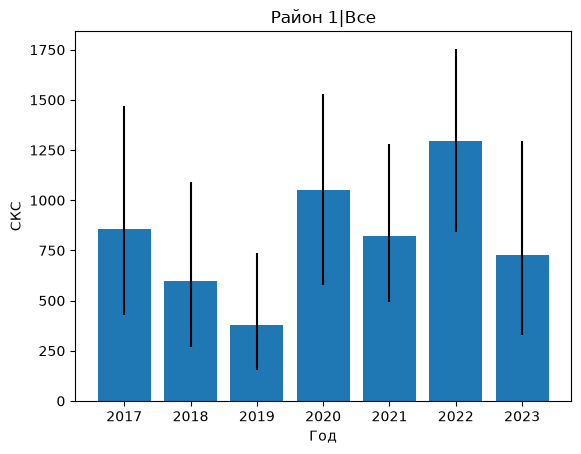

In [48]:
# Значения СКС по годам для Района 1 и всех причин смерти.
# Срез по df_result.
plt_df=df_result[(df_result['Муниципалитет']=='Район 1')&(df_result['Пол']=='Все')&(df_result['Причина смерти']=='Все')]
# Преобразование значений границ ДИ в формат, поддерживаемый seaborn.
plt_df['Нижняя граница ДИ (95%)'] = plt_df['СКС']-plt_df['Нижняя граница ДИ (95%)']
plt_df['Верхняя граница ДИ (95%)'] = plt_df['Верхняя граница ДИ (95%)']-plt_df['СКС']

# Построение барплота.
fig, ax = plt.subplots()

ax.bar(x=plt_df['Год'].tolist(), height=plt_df['СКС'].tolist(),
        yerr=[plt_df['Нижняя граница ДИ (95%)'].tolist(), plt_df['Верхняя граница ДИ (95%)'].tolist()])

ax.set_xlabel('Год')
ax.set_ylabel('СКС')
ax.set_title('Район 1|Все')

plt.show()

In [49]:
plt_df

,Муниципалитет,Год,Пол,Причина смерти,Численность населения,Число умерших,СКС,Нижняя граница ДИ (95%),Верхняя граница ДИ (95%),Значимость СКС (p < 0.05)
0,Район 1,2017,Все,Все,4445,19,858.284639,431.796737,609.414988,Да
1,Район 1,2018,Все,Все,4409,14,597.988649,328.126791,490.665728,Да
2,Район 1,2019,Все,Все,4378,11,379.817689,227.594494,358.693353,Да
3,Район 1,2020,Все,Все,4346,25,1051.377639,476.119136,476.119136,Да
4,Район 1,2021,Все,Все,4226,22,823.436035,331.862127,456.948000,Да
5,Район 1,2022,Все,Все,4161,35,1297.124613,456.783741,456.783741,Да
6,Район 1,2023,Все,Все,4105,17,726.123936,396.085094,570.315036,Да


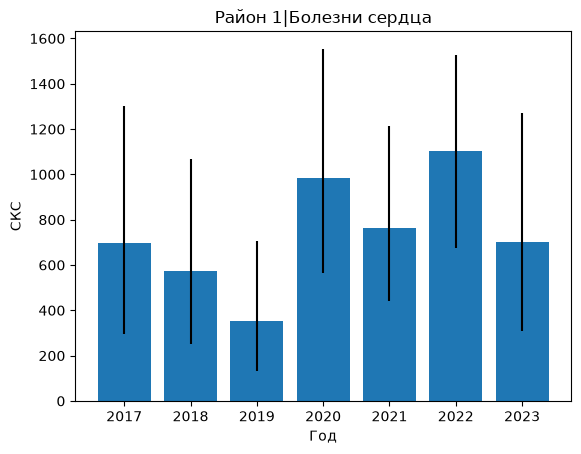

In [50]:
# Значения СКС по годам для Района 1 и болезней сердца.
# Срез по df_result.
plt_df=df_result[(df_result['Муниципалитет']=='Район 1')&(df_result['Причина смерти']=='Болезни сердца')]
# Преобразование значений границ ДИ в формат, поддерживаемый seaborn.
plt_df['Нижняя граница ДИ (95%)'] = plt_df['СКС']-plt_df['Нижняя граница ДИ (95%)']
plt_df['Верхняя граница ДИ (95%)'] = plt_df['Верхняя граница ДИ (95%)']-plt_df['СКС']

# Построение барплота.
fig, ax = plt.subplots()

ax.bar(x=plt_df['Год'].tolist(), height=plt_df['СКС'].tolist(),
        yerr=[plt_df['Нижняя граница ДИ (95%)'].tolist(), plt_df['Верхняя граница ДИ (95%)'].tolist()])

ax.set_xlabel('Год')
ax.set_ylabel('СКС')
ax.set_title('Район 1|Болезни сердца')

plt.show()

In [51]:
plt_df

,Муниципалитет,Год,Пол,Причина смерти,Численность населения,Число умерших,СКС,Нижняя граница ДИ (95%),Верхняя граница ДИ (95%),Значимость СКС (p < 0.05)
63,Район 1,2017,Все,Болезни сердца,4445,14,699.307095,401.773316,600.793359,Да
67,Район 1,2018,Все,Болезни сердца,4409,13,574.822626,323.785353,491.714978,Да
71,Район 1,2019,Все,Болезни сердца,4378,10,351.591883,220.684079,355.764896,Да
75,Район 1,2020,Все,Болезни сердца,4346,23,982.891049,417.528011,570.819793,Да
79,Район 1,2021,Все,Болезни сердца,4226,20,764.266186,321.729783,450.070569,Да
83,Район 1,2022,Все,Болезни сердца,4161,29,1102.869702,425.905386,425.905386,Да
87,Район 1,2023,Все,Болезни сердца,4105,16,701.219721,392.022285,570.937402,Да


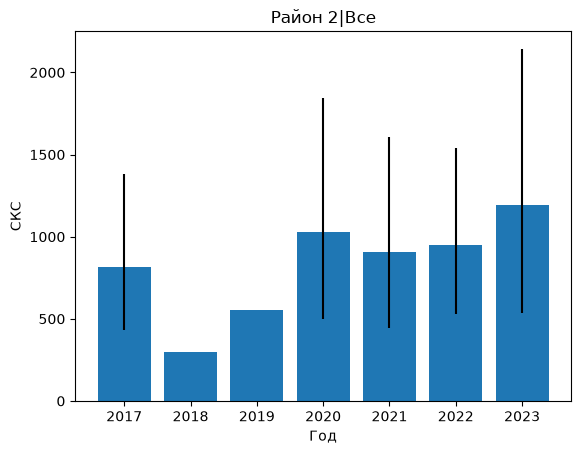

In [52]:
# Значения СКС по годам для Района 2 и всех причин смерти.
# Срез по df_result.
plt_df=df_result[(df_result['Муниципалитет']=='Район 2')&(df_result['Пол']=='Все')&(df_result['Причина смерти']=='Все')]
# Преобразование значений границ ДИ в формат, поддерживаемый seaborn.
plt_df['Нижняя граница ДИ (95%)'] = plt_df['СКС']-plt_df['Нижняя граница ДИ (95%)']
plt_df['Верхняя граница ДИ (95%)'] = plt_df['Верхняя граница ДИ (95%)']-plt_df['СКС']

# Построение барплота.
fig, ax = plt.subplots()

ax.bar(x=plt_df['Год'].tolist(), height=plt_df['СКС'].tolist(),
        yerr=[plt_df['Нижняя граница ДИ (95%)'].tolist(), plt_df['Верхняя граница ДИ (95%)'].tolist()])

ax.set_xlabel('Год')
ax.set_ylabel('СКС')
ax.set_title('Район 2|Все')

plt.show()

In [53]:
plt_df

,Муниципалитет,Год,Пол,Причина смерти,Численность населения,Число умерших,СКС,Нижняя граница ДИ (95%),Верхняя граница ДИ (95%),Значимость СКС (p < 0.05)
7,Район 2,2017,Все,Все,2962,15,815.255235,382.491825,564.083559,Да
8,Район 2,2018,Все,Все,2956,7,300.620512,NaN,NaN,Нет
9,Район 2,2019,Все,Все,2941,8,556.633277,NaN,NaN,Нет
10,Район 2,2020,Все,Все,2925,13,1031.119659,533.881725,810.776765,Да
11,Район 2,2021,Все,Все,2974,14,908.643625,465.926873,696.725641,Да
12,Район 2,2022,Все,Все,2900,18,947.552217,417.977814,595.594208,Да
13,Район 2,2023,Все,Все,2582,16,1190.964551,653.852281,952.264033,Да


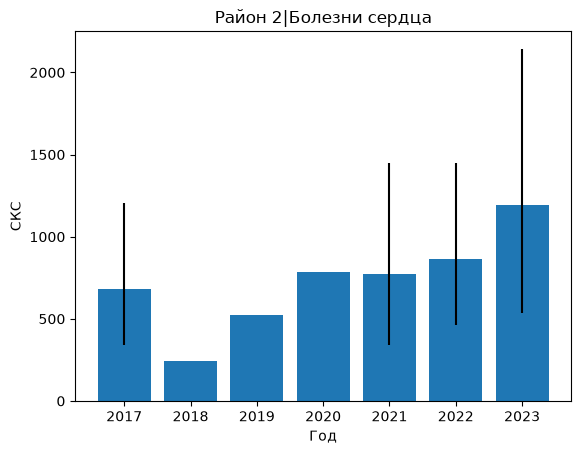

In [54]:
# Значения СКС по годам для Района 1 и болезней сердца.
# Срез по df_result.
plt_df=df_result[(df_result['Муниципалитет']=='Район 2')&(df_result['Причина смерти']=='Болезни сердца')]
# Преобразование значений границ ДИ в формат, поддерживаемый seaborn.
plt_df['Нижняя граница ДИ (95%)'] = plt_df['СКС']-plt_df['Нижняя граница ДИ (95%)']
plt_df['Верхняя граница ДИ (95%)'] = plt_df['Верхняя граница ДИ (95%)']-plt_df['СКС']

# Построение барплота.
fig, ax = plt.subplots()

ax.bar(x=plt_df['Год'].tolist(), height=plt_df['СКС'].tolist(),
        yerr=[plt_df['Нижняя граница ДИ (95%)'].tolist(), plt_df['Верхняя граница ДИ (95%)'].tolist()])

ax.set_xlabel('Год')
ax.set_ylabel('СКС')
ax.set_title('Район 2|Болезни сердца')

plt.show()

In [55]:
plt_df

,Муниципалитет,Год,Пол,Причина смерти,Численность населения,Число умерших,СКС,Нижняя граница ДИ (95%),Верхняя граница ДИ (95%),Значимость СКС (p < 0.05)
91,Район 2,2017,Все,Болезни сердца,2962,13,682.902294,343.171245,521.155265,Да
95,Район 2,2018,Все,Болезни сердца,2956,6,246.165067,NaN,NaN,Нет
99,Район 2,2019,Все,Болезни сердца,2941,7,521.114152,NaN,NaN,Нет
103,Район 2,2020,Все,Болезни сердца,2925,9,786.889211,NaN,NaN,Нет
107,Район 2,2021,Все,Болезни сердца,2974,11,770.408916,431.780094,680.493835,Да
111,Район 2,2022,Все,Болезни сердца,2900,16,862.991388,401.491641,584.728479,Да
115,Район 2,2023,Все,Болезни сердца,2582,16,1190.964551,653.852281,952.264033,Да


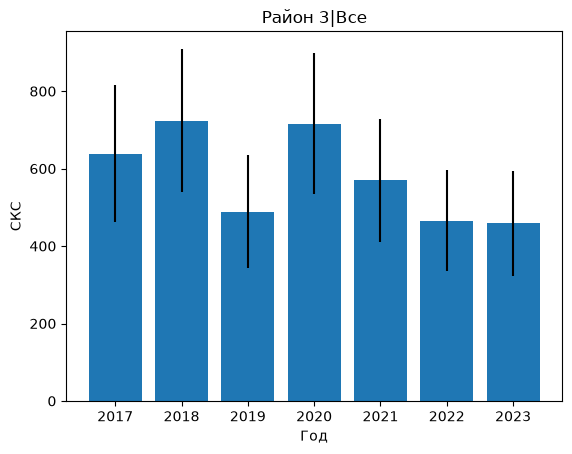

In [56]:
# Значения СКС по годам для Района 3 и всех причин смерти.
# Срез по df_result.
plt_df=df_result[(df_result['Муниципалитет']=='Район 3')&(df_result['Пол']=='Все')&(df_result['Причина смерти']=='Все')]
# Преобразование значений границ ДИ в формат, поддерживаемый seaborn.
plt_df['Нижняя граница ДИ (95%)'] = plt_df['СКС']-plt_df['Нижняя граница ДИ (95%)']
plt_df['Верхняя граница ДИ (95%)'] = plt_df['Верхняя граница ДИ (95%)']-plt_df['СКС']

# Построение барплота.
fig, ax = plt.subplots()

ax.bar(x=plt_df['Год'].tolist(), height=plt_df['СКС'].tolist(),
        yerr=[plt_df['Нижняя граница ДИ (95%)'].tolist(), plt_df['Верхняя граница ДИ (95%)'].tolist()])

ax.set_xlabel('Год')
ax.set_ylabel('СКС')
ax.set_title('Район 3|Все')

plt.show()

In [57]:
plt_df

,Муниципалитет,Год,Пол,Причина смерти,Численность населения,Число умерших,СКС,Нижняя граница ДИ (95%),Верхняя граница ДИ (95%),Значимость СКС (p < 0.05)
14,Район 3,2017,Все,Все,24654,67,638.790895,176.124465,176.124465,Да
15,Район 3,2018,Все,Все,24775,71,724.049588,185.047051,185.047051,Да
16,Район 3,2019,Все,Все,26760,58,488.870696,146.186699,146.186699,Да
17,Район 3,2020,Все,Все,27084,77,716.247235,182.953771,182.953771,Да
18,Район 3,2021,Все,Все,27567,65,569.558940,158.026849,158.026849,Да
19,Район 3,2022,Все,Все,28261,61,465.520713,130.105356,130.105356,Да
20,Район 3,2023,Все,Все,25717,54,458.628755,136.342462,136.342462,Да


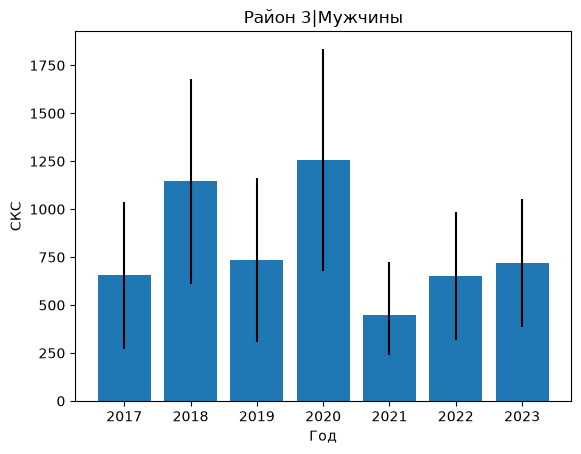

In [58]:
# Значения СКС по годам для мужской смертности Района 3.
# Срез по df_result.
plt_df=df_result[(df_result['Муниципалитет']=='Район 3')&(df_result['Пол']=='Мужчины')]
# Преобразование значений границ ДИ в формат, поддерживаемый seaborn.
plt_df['Нижняя граница ДИ (95%)'] = plt_df['СКС']-plt_df['Нижняя граница ДИ (95%)']
plt_df['Верхняя граница ДИ (95%)'] = plt_df['Верхняя граница ДИ (95%)']-plt_df['СКС']

# Построение барплота.
fig, ax = plt.subplots()

ax.bar(x=plt_df['Год'].tolist(), height=plt_df['СКС'].tolist(),
        yerr=[plt_df['Нижняя граница ДИ (95%)'].tolist(), plt_df['Верхняя граница ДИ (95%)'].tolist()])

ax.set_xlabel('Год')
ax.set_ylabel('СКС')
ax.set_title('Район 3|Мужчины')

plt.show()

In [59]:
plt_df

,Муниципалитет,Год,Пол,Причина смерти,Численность населения,Число умерших,СКС,Нижняя граница ДИ (95%),Верхняя граница ДИ (95%),Значимость СКС (p < 0.05)
50,Район 3,2017,Мужчины,Все,11669,30,654.268312,382.621403,382.621403,Да
52,Район 3,2018,Мужчины,Все,11727,34,1145.928235,535.191141,535.191141,Да
54,Район 3,2019,Мужчины,Все,12698,29,733.986634,425.951140,425.951140,Да
56,Район 3,2020,Мужчины,Все,12908,44,1256.505020,578.812715,578.812715,Да
58,Район 3,2021,Мужчины,Все,13086,24,447.021574,205.517938,279.103060,Да
60,Район 3,2022,Мужчины,Все,13443,32,649.616917,334.025753,334.025753,Да
62,Район 3,2023,Мужчины,Все,12024,33,721.231511,333.943699,333.943699,Да


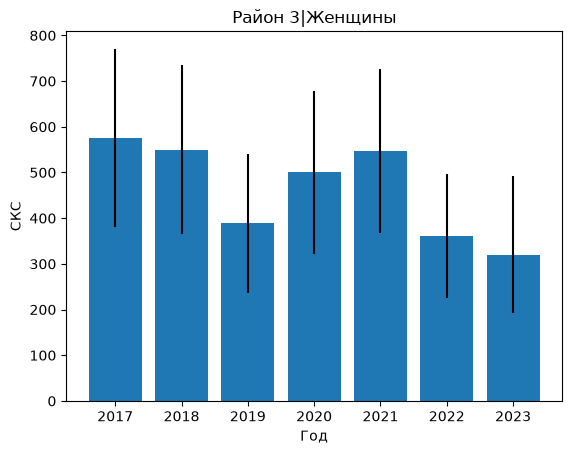

In [60]:
# Значения СКС по годам для женской смертности Района 3.
# Срез по df_result.
plt_df=df_result[(df_result['Муниципалитет']=='Район 3')&(df_result['Пол']=='Женщины')]
# Преобразование значений границ ДИ в формат, поддерживаемый seaborn.
plt_df['Нижняя граница ДИ (95%)'] = plt_df['СКС']-plt_df['Нижняя граница ДИ (95%)']
plt_df['Верхняя граница ДИ (95%)'] = plt_df['Верхняя граница ДИ (95%)']-plt_df['СКС']

# Построение барплота.
fig, ax = plt.subplots()

ax.bar(x=plt_df['Год'].tolist(), height=plt_df['СКС'].tolist(),
        yerr=[plt_df['Нижняя граница ДИ (95%)'].tolist(), plt_df['Верхняя граница ДИ (95%)'].tolist()])

ax.set_xlabel('Год')
ax.set_ylabel('СКС')
ax.set_title('Район 3|Женщины')

plt.show()

In [61]:
plt_df

,Муниципалитет,Год,Пол,Причина смерти,Численность населения,Число умерших,СКС,Нижняя граница ДИ (95%),Верхняя граница ДИ (95%),Значимость СКС (p < 0.05)
49,Район 3,2017,Женщины,Все,12985,37,575.416559,194.949635,194.949635,Да
51,Район 3,2018,Женщины,Все,13048,37,550.267523,184.606307,184.606307,Да
53,Район 3,2019,Женщины,Все,14062,29,388.353656,151.868963,151.868963,Да
55,Район 3,2020,Женщины,Все,14176,33,500.112714,179.107179,179.107179,Да
57,Район 3,2021,Женщины,Все,14481,41,547.478378,179.058379,179.058379,Да
59,Район 3,2022,Женщины,Все,14818,29,360.951423,136.442835,136.442835,Да
61,Район 3,2023,Женщины,Все,13693,21,318.595241,125.323666,173.883492,Да


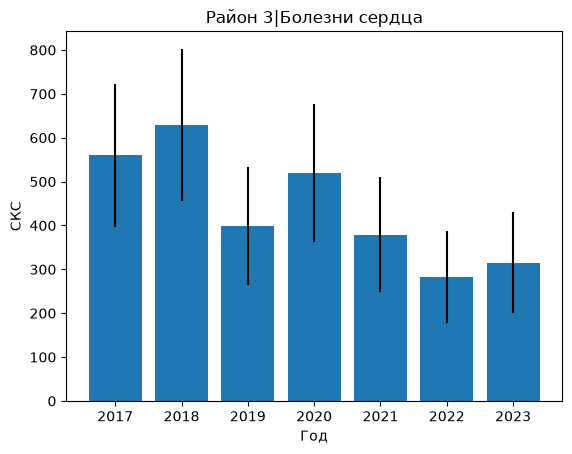

In [62]:
# Значения СКС по годам для Района 3 и болезней сердца.
# Срез по df_result.
plt_df=df_result[(df_result['Муниципалитет']=='Район 3')&(df_result['Причина смерти']=='Болезни сердца')]
# Преобразование значений границ ДИ в формат, поддерживаемый seaborn.
plt_df['Нижняя граница ДИ (95%)'] = plt_df['СКС']-plt_df['Нижняя граница ДИ (95%)']
plt_df['Верхняя граница ДИ (95%)'] = plt_df['Верхняя граница ДИ (95%)']-plt_df['СКС']

# Построение барплота.
fig, ax = plt.subplots()

ax.bar(x=plt_df['Год'].tolist(), height=plt_df['СКС'].tolist(),
        yerr=[plt_df['Нижняя граница ДИ (95%)'].tolist(), plt_df['Верхняя граница ДИ (95%)'].tolist()])

ax.set_xlabel('Год')
ax.set_ylabel('СКС')
ax.set_title('Район 3|Болезни сердца')

plt.show()

In [63]:
plt_df

,Муниципалитет,Год,Пол,Причина смерти,Численность населения,Число умерших,СКС,Нижняя граница ДИ (95%),Верхняя граница ДИ (95%),Значимость СКС (p < 0.05)
119,Район 3,2017,Все,Болезни сердца,24654,60,559.728244,162.653043,162.653043,Да
123,Район 3,2018,Все,Болезни сердца,24775,61,629.173264,173.253282,173.253282,Да
127,Район 3,2019,Все,Болезни сердца,26760,46,399.212468,134.454740,134.454740,Да
131,Район 3,2020,Все,Болезни сердца,27084,56,520.209359,157.021593,157.021593,Да
135,Район 3,2021,Все,Болезни сердца,27567,42,379.257733,131.538367,131.538367,Да
139,Район 3,2022,Все,Болезни сердца,28261,35,282.297484,104.755387,104.755387,Да
143,Район 3,2023,Все,Болезни сердца,25717,37,315.576643,114.409730,114.409730,Да


In [64]:
# Т.к. ДИ для этой группы симметричны и из барплота можно предположить наличие некоторого тренда
# посчитаем коэффициент фзвешенной линейной регрессии и оценим его статистическую значимость.
weighted_regression(df_result[(df_result['Муниципалитет']=='Район 3')&(df_result['Причина смерти']=='Болезни сердца')])

(-50.30456471004132, 'Да')

In [65]:
# Вывод:
# 1) Есть статистически значимое наличие тренда к снижению смертности от болезней сердца в Районе 3.

#### По причинам смерти

In [66]:
# Идея: посмотреть на значения СКС по годам для каждого района по причинам смерти (болезни сердца / остальные причины смерти)
# безотносительно статистической значимости значений СКС.

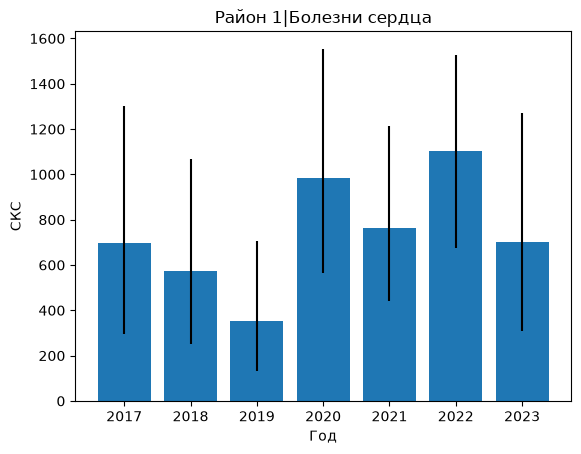

In [67]:
# Значения СКС по годам для Района 1 и болезней сердца.
# Список, куда будут сохраняться строки будующей таблицы.
strings_list = []
# Итеррирование по годам.
for year in all_years_list:
    # Создание необходимого среза по df.
    df_slice = (df[(df['Муниципалитет']=='Район 1')&(df['Год']==year)&(df['Причина смерти']=='Болезни сердца')]
            .groupby(['Возрастная группа', 'Стандартный вес группы', 'Пол'], as_index=False)
            .agg({'Число умерших': 'sum', 'Численность населения': 'first'}))
    df_slice = (df_slice.groupby(['Возрастная группа', 'Стандартный вес группы'], as_index=False)
            .agg({'Число умерших': 'sum', 'Численность населения': 'sum'}))
    # Добавление строки новой таблицы.
    strings_list.append(['Район 1', year, 'Все', 'Остальные причины'] + list(N_D_SCR_CI_calc(df_slice, alpha)))
# Создание таблицы из списка strings_list.
plt_df = pd.DataFrame(strings_list, columns=columns_list)

# Преобразование значений границ ДИ в формат, поддерживаемый seaborn.
plt_df['Нижняя граница ДИ (95%)'] = plt_df['СКС']-plt_df['Нижняя граница ДИ (95%)']
plt_df['Верхняя граница ДИ (95%)'] = plt_df['Верхняя граница ДИ (95%)']-plt_df['СКС']

# Построение барплота.
fig, ax = plt.subplots()

ax.bar(x=plt_df['Год'].tolist(), height=plt_df['СКС'].tolist(),
        yerr=[plt_df['Нижняя граница ДИ (95%)'].tolist(), plt_df['Верхняя граница ДИ (95%)'].tolist()])

ax.set_xlabel('Год')
ax.set_ylabel('СКС')
ax.set_title('Район 1|Болезни сердца')

plt.show()

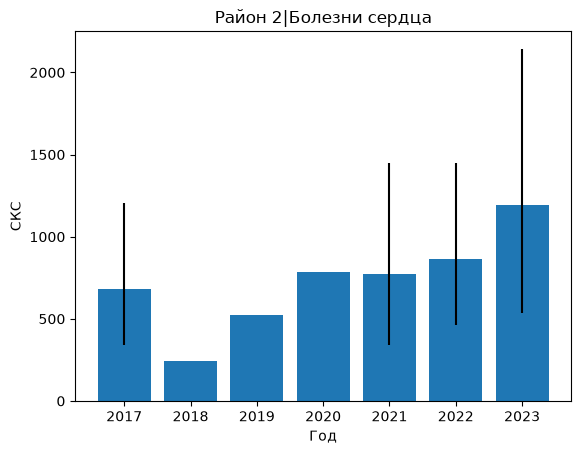

In [68]:
# Значения СКС по годам для Района 2 и болезней сердца.
# Список, куда будут сохраняться строки будующей таблицы.
strings_list = []
# Итеррирование по годам.
for year in all_years_list:
    # Создание необходимого среза по df.
    df_slice = (df[(df['Муниципалитет']=='Район 2')&(df['Год']==year)&(df['Причина смерти']=='Болезни сердца')]
            .groupby(['Возрастная группа', 'Стандартный вес группы', 'Пол'], as_index=False)
            .agg({'Число умерших': 'sum', 'Численность населения': 'first'}))
    df_slice = (df_slice.groupby(['Возрастная группа', 'Стандартный вес группы'], as_index=False)
            .agg({'Число умерших': 'sum', 'Численность населения': 'sum'}))
    # Добавление строки новой таблицы.
    strings_list.append(['Район 2', year, 'Все', 'Остальные причины'] + list(N_D_SCR_CI_calc(df_slice, alpha)))
# Создание таблицы из списка strings_list.
plt_df = pd.DataFrame(strings_list, columns=columns_list)

# Преобразование значений границ ДИ в формат, поддерживаемый seaborn.
plt_df['Нижняя граница ДИ (95%)'] = plt_df['СКС']-plt_df['Нижняя граница ДИ (95%)']
plt_df['Верхняя граница ДИ (95%)'] = plt_df['Верхняя граница ДИ (95%)']-plt_df['СКС']

# Построение барплота.
fig, ax = plt.subplots()

ax.bar(x=plt_df['Год'].tolist(), height=plt_df['СКС'].tolist(),
        yerr=[plt_df['Нижняя граница ДИ (95%)'].tolist(), plt_df['Верхняя граница ДИ (95%)'].tolist()])

ax.set_xlabel('Год')
ax.set_ylabel('СКС')
ax.set_title('Район 2|Болезни сердца')

plt.show()

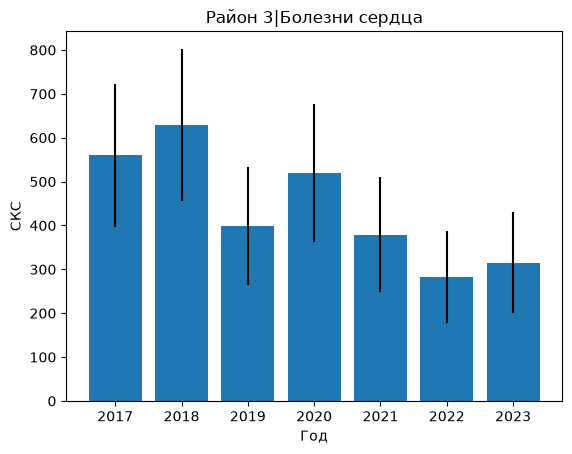

In [69]:
# Значения СКС по годам для Района 3 и болезней сердца.
# Список, куда будут сохраняться строки будующей таблицы.
strings_list = []
# Итеррирование по годам.
for year in all_years_list:
    # Создание необходимого среза по df.
    df_slice = (df[(df['Муниципалитет']=='Район 3')&(df['Год']==year)&(df['Причина смерти']=='Болезни сердца')]
            .groupby(['Возрастная группа', 'Стандартный вес группы', 'Пол'], as_index=False)
            .agg({'Число умерших': 'sum', 'Численность населения': 'first'}))
    df_slice = (df_slice.groupby(['Возрастная группа', 'Стандартный вес группы'], as_index=False)
            .agg({'Число умерших': 'sum', 'Численность населения': 'sum'}))
    # Добавление строки новой таблицы.
    strings_list.append(['Район 2', year, 'Все', 'Остальные причины'] + list(N_D_SCR_CI_calc(df_slice, alpha)))
# Создание таблицы из списка strings_list.
plt_df = pd.DataFrame(strings_list, columns=columns_list)

# Преобразование значений границ ДИ в формат, поддерживаемый seaborn.
plt_df['Нижняя граница ДИ (95%)'] = plt_df['СКС']-plt_df['Нижняя граница ДИ (95%)']
plt_df['Верхняя граница ДИ (95%)'] = plt_df['Верхняя граница ДИ (95%)']-plt_df['СКС']

# Построение барплота.
fig, ax = plt.subplots()

ax.bar(x=plt_df['Год'].tolist(), height=plt_df['СКС'].tolist(),
        yerr=[plt_df['Нижняя граница ДИ (95%)'].tolist(), plt_df['Верхняя граница ДИ (95%)'].tolist()])

ax.set_xlabel('Год')
ax.set_ylabel('СКС')
ax.set_title('Район 3|Болезни сердца')

plt.show()

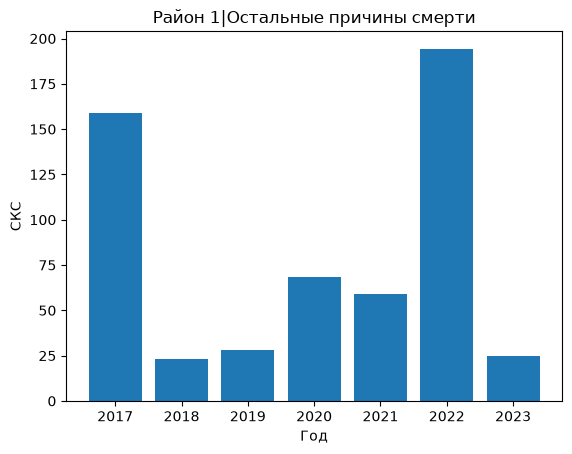

In [70]:
# Значения СКС по годам для Района 1 и всех причин кроме болезней сердца.
# Список, куда будут сохраняться строки будующей таблицы.
strings_list = []
# Итеррирование по годам.
for year in all_years_list:
    # Создание необходимого среза по df.
    df_slice = (df[(df['Муниципалитет']=='Район 1')&(df['Год']==year)&(df['Причина смерти']!='Болезни сердца')]
            .groupby(['Возрастная группа', 'Стандартный вес группы', 'Пол'], as_index=False)
            .agg({'Число умерших': 'sum', 'Численность населения': 'first'}))
    df_slice = (df_slice.groupby(['Возрастная группа', 'Стандартный вес группы'], as_index=False)
            .agg({'Число умерших': 'sum', 'Численность населения': 'sum'}))
    # Добавление строки новой таблицы.
    strings_list.append(['Район 1', year, 'Все', 'Остальные причины'] + list(N_D_SCR_CI_calc(df_slice, alpha)))
# Создание таблицы из списка strings_list.
plt_df = pd.DataFrame(strings_list, columns=columns_list)

# Преобразование значений границ ДИ в формат, поддерживаемый seaborn.
plt_df['Нижняя граница ДИ (95%)'] = plt_df['СКС']-plt_df['Нижняя граница ДИ (95%)']
plt_df['Верхняя граница ДИ (95%)'] = plt_df['Верхняя граница ДИ (95%)']-plt_df['СКС']

# Построение барплота.
fig, ax = plt.subplots()

ax.bar(x=plt_df['Год'].tolist(), height=plt_df['СКС'].tolist(),
        yerr=[plt_df['Нижняя граница ДИ (95%)'].tolist(), plt_df['Верхняя граница ДИ (95%)'].tolist()])

ax.set_xlabel('Год')
ax.set_ylabel('СКС')
ax.set_title('Район 1|Остальные причины смерти')

plt.show()

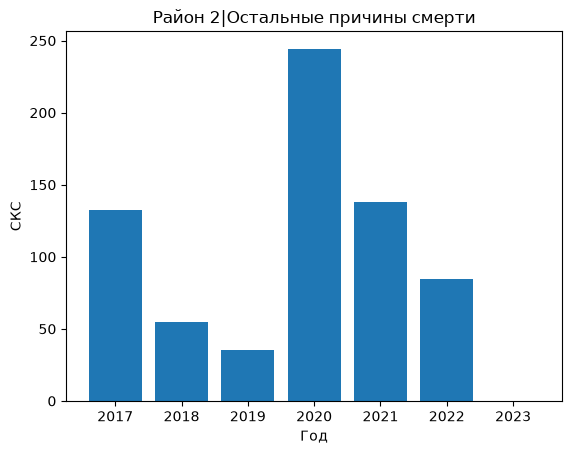

In [71]:
# Значения СКС по годам для Района 2 и всех причин кроме болезней сердца.
# Список, куда будут сохраняться строки будующей таблицы.
strings_list = []
# Итеррирование по годам.
for year in all_years_list:
    # Создание необходимого среза по df.
    df_slice = (df[(df['Муниципалитет']=='Район 2')&(df['Год']==year)&(df['Причина смерти']!='Болезни сердца')]
            .groupby(['Возрастная группа', 'Стандартный вес группы', 'Пол'], as_index=False)
            .agg({'Число умерших': 'sum', 'Численность населения': 'first'}))
    df_slice = (df_slice.groupby(['Возрастная группа', 'Стандартный вес группы'], as_index=False)
            .agg({'Число умерших': 'sum', 'Численность населения': 'sum'}))
    # Добавление строки новой таблицы.
    strings_list.append(['Район 2', year, 'Все', 'Остальные причины'] + list(N_D_SCR_CI_calc(df_slice, alpha)))
# Создание таблицы из списка strings_list.
plt_df = pd.DataFrame(strings_list, columns=columns_list)

# Преобразование значений границ ДИ в формат, поддерживаемый seaborn.
plt_df['Нижняя граница ДИ (95%)'] = plt_df['СКС']-plt_df['Нижняя граница ДИ (95%)']
plt_df['Верхняя граница ДИ (95%)'] = plt_df['Верхняя граница ДИ (95%)']-plt_df['СКС']

# Построение барплота.
fig, ax = plt.subplots()

ax.bar(x=plt_df['Год'].tolist(), height=plt_df['СКС'].tolist(),
        yerr=[plt_df['Нижняя граница ДИ (95%)'].tolist(), plt_df['Верхняя граница ДИ (95%)'].tolist()])

ax.set_xlabel('Год')
ax.set_ylabel('СКС')
ax.set_title('Район 2|Остальные причины смерти')

plt.show()

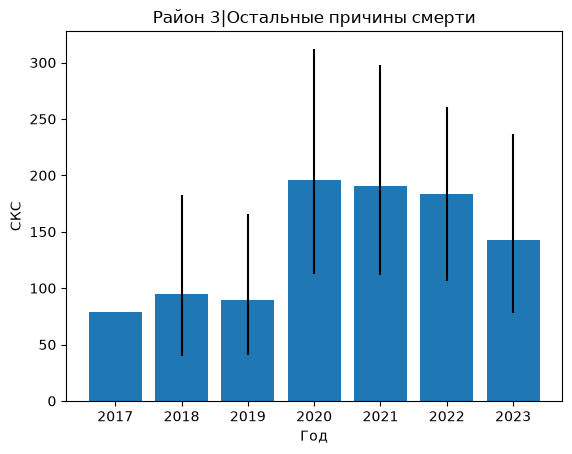

In [72]:
# Значения СКС по годам для Района 3 и всех причин кроме болезней сердца.
# Список, куда будут сохраняться строки будующей таблицы.
strings_list = []
# Итеррирование по годам.
for year in all_years_list:
    # Создание необходимого среза по df.
    df_slice = (df[(df['Муниципалитет']=='Район 3')&(df['Год']==year)&(df['Причина смерти']!='Болезни сердца')]
            .groupby(['Возрастная группа', 'Стандартный вес группы', 'Пол'], as_index=False)
            .agg({'Число умерших': 'sum', 'Численность населения': 'first'}))
    df_slice = (df_slice.groupby(['Возрастная группа', 'Стандартный вес группы'], as_index=False)
            .agg({'Число умерших': 'sum', 'Численность населения': 'sum'}))
    # Добавление строки новой таблицы.
    strings_list.append(['Район 2', year, 'Все', 'Остальные причины'] + list(N_D_SCR_CI_calc(df_slice, alpha)))
# Создание таблицы из списка strings_list.
plt_df = pd.DataFrame(strings_list, columns=columns_list)

# Преобразование значений границ ДИ в формат, поддерживаемый seaborn.
plt_df['Нижняя граница ДИ (95%)'] = plt_df['СКС']-plt_df['Нижняя граница ДИ (95%)']
plt_df['Верхняя граница ДИ (95%)'] = plt_df['Верхняя граница ДИ (95%)']-plt_df['СКС']

# Построение барплота.
fig, ax = plt.subplots()

ax.bar(x=plt_df['Год'].tolist(), height=plt_df['СКС'].tolist(),
        yerr=[plt_df['Нижняя граница ДИ (95%)'].tolist(), plt_df['Верхняя граница ДИ (95%)'].tolist()])

ax.set_xlabel('Год')
ax.set_ylabel('СКС')
ax.set_title('Район 3|Остальные причины смерти')

plt.show()

In [73]:
# Вывод: хотя значения СКС в большинстве своём статистически неразличимы либо вообще не имеют статистически значимого отличия от нуля,
# кажется, что их изменение с течением времени скоррелированы. Это следует проверить.

# Выводы

In [74]:
# Общий вывод:
# Между муниципалитетами по годам:
# 1) Район 1 и Район 2 не отличаются по структуре смертности.
# 2) В Районе 3 женская смертность, смерность ото всех причин и смертность от болезней сердца ниже, чем в Районе 1.
# 3) В Районе 3 смертность от болезней сердца ниже чем в Районе 2.
# Между муниципалитетами за период:
# 1) Район 1 и Район 2 не отличаются по структуре смертности.
# 2) В Районе 3 женская смертность и смертность от болезней сердца ниже, чем в Районах 1 и 2.
# и смертность от других болезней органов дыхания выше в Районе 3, чем в районе 1. Что говорит об отличной от Районов 1 и 2 структуре смертности.
# Внутри муниципалитетов по годам:
# 1) В Районах 1 и 3 женская смертность равна мужской.
# 2) В Районе 3 смертность от болезней сердца выше, чем от остальных причин.
# Внутри муниципалитетов за период:
# 1) В Районах 1, 2 и 3 смертность от болезней сердца превышает смертность от остальных причин.
# 2) Районах 1 и 2 женская смертность не отличается от мужской.
# 3) В Районе 3 женская смертность ниже мужской.
# Динамика и тренды:
# 1) Есть статистически значимый тренд на снижение смертности от болезней сердца в Районе 3.
# 2) Возможно наличие корреляции изменения смертности с течением времени между районами. Это требует проверки.